In [1]:
%pip install torch torchvision scikit-learn matplotlib pillow

  Using cached torch-2.10.0-cp314-cp314-win_amd64.whl.metadata (31 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 1.0/113.8 MB 6.1 MB/s eta 0:00:19
    --------------------------------------- 2.1/113.8 MB 5.9 MB/s eta 0:00:19
   - -------------------------------------- 3.4/113.8 MB 5.8 MB/s eta 0:00:19
   - -------------------------------------- 4.5/113.8 MB 5.8 MB/s eta 0:00:19
   - -------------------------------------- 5.5/113.8 MB 5.6 MB/s eta 0:00:20
   -- ------------------------------------- 5.8/113.8 MB 5.0 MB/s eta 0:00:22
   -- ------------------------------------- 6.6/113.8 MB 4.7 MB/s eta 0:00:23
   -- ------------------------------------- 7.6/113.8 MB 4.7 MB/s eta 0:00:23
   --- ----------------------------

In [ ]:
# MULTI-CANCER CLASSIFICATION (FAST SAMPLE VERSION)

import os
import shutil
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from PIL import Image
import torchvision

random.seed(42)
torch.manual_seed(42)

# PATHS
SOURCE_DIR = "C:/Files/IISc/AI in Health Care/Multi Cancer/Multi Cancer/Input"
SELECTED_CANCER = "Breast Cancer"

DEST_DIR = r"C:/Files/IISc/AI in Health Care/Multi Cancer/Multi Cancer/data_split_breast"


# number of images per class 
MAX_IMAGES_PER_CLASS = 5000

SPLITS = {"train": 0.7, "val": 0.15, "test": 0.15}
VALID_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

# MODEL SAVE PATH
MODEL_DIR = "C:/Files/IISc/AI in Health Care/Multi Cancer/Multi Cancer/saved_model/breast"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, "multi_cancer_densenet121_breast.pth")
META_PATH = os.path.join(MODEL_DIR, "model_metadata_breast.pth")

In [ ]:
# DATA SPLIT FUNCTION 
def split_dataset():

    cancer_path = os.path.join(SOURCE_DIR, SELECTED_CANCER)

    if not os.path.exists(cancer_path):
        print(f"Cancer folder not found: {SELECTED_CANCER}")
        return

    if os.path.exists(DEST_DIR):
        print("Split already exists — skipping...")
        return

    print(f"\nCreating split for: {SELECTED_CANCER}\n")

    # iterate over subtype folders
    for subtype in os.listdir(cancer_path):

        subtype_path = os.path.join(cancer_path, subtype)

        if not os.path.isdir(subtype_path):
            continue

        print(f"\nProcessing subtype: {subtype}")

        # collect valid images
        images = [
            f for f in os.listdir(subtype_path)
            if f.lower().endswith(VALID_EXT)
        ]

        if len(images) == 0:
            print("⚠ No images found — skipping")
            continue

        # shuffle
        random.shuffle(images)

        # sample limit
        images = images[:MAX_IMAGES_PER_CLASS]

        n = len(images)

        train_end = int(n * SPLITS["train"])
        val_end = train_end + int(n * SPLITS["val"])

        split_map = {
            "train": images[:train_end],
            "val": images[train_end:val_end],
            "test": images[val_end:]
        }

        # copy files
        for split, files in split_map.items():

            dest_folder = os.path.join(
                DEST_DIR,
                split,
                subtype   # subtype becomes class label
            )

            os.makedirs(dest_folder, exist_ok=True)

            for f in files:
                shutil.copy2(
                    os.path.join(subtype_path, f),
                    os.path.join(dest_folder, f)
                )

            print(f"{split}: {len(files)} images")

    print("\nDataset split completed successfully!")

In [ ]:
# DATA LOADING
IMG_SIZE = 128          # smaller image
BATCH_SIZE = 16         # smaller batch

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = datasets.ImageFolder(
    f"{DEST_DIR}/train", transform=transform)

val_dataset = datasets.ImageFolder(
    f"{DEST_DIR}/val", transform=transform)

test_dataset = datasets.ImageFolder(
    f"{DEST_DIR}/test", transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print("Classes:", train_dataset.classes)



Classes: ['breast_benign', 'breast_malignant']


In [ ]:
# MODEL — DenseNet121 

from torchvision.models import densenet121, DenseNet121_Weights

model = densenet121(weights=DenseNet121_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_classes = len(train_dataset.classes)

model.classifier = nn.Linear(
    model.classifier.in_features,
    num_classes
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# move model once
model = model.to(device)

In [ ]:
# TRAIN SETUP
criterion = nn.CrossEntropyLoss()

# Optimize only classifier (since backbone is frozen)
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

In [ ]:
#  TRAINING LOOP (FAST)
def train_model(epochs=10):

    for epoch in range(epochs):

        model.train()
        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss:.4f}")

# SAVE MODEL
def save_model():

    print("Saving trained model...")

    torch.save({
        "model_state_dict": model.state_dict(),
        "num_classes": num_classes,
        "class_to_idx": train_dataset.class_to_idx,
        "img_size": IMG_SIZE
    }, MODEL_PATH)

    print(f"Model saved at: {MODEL_PATH}")




In [7]:

train_model()
save_model()

c:\Files\IISc\AI in Health Care\Multi Cancer\Multi Cancer\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 | Loss: 137.6015
Epoch 2/10 | Loss: 102.6510
Epoch 3/10 | Loss: 93.3851
Epoch 4/10 | Loss: 90.2163
Epoch 5/10 | Loss: 82.0258
Epoch 6/10 | Loss: 79.6371
Epoch 7/10 | Loss: 79.4406
Epoch 8/10 | Loss: 80.2737
Epoch 9/10 | Loss: 81.3131
Epoch 10/10 | Loss: 82.3976
Saving trained model...
Model saved at: C:/Files/IISc/AI in Health Care/Multi Cancer/Multi Cancer/saved_model/breast\multi_cancer_densenet121_breast.pth


In [ ]:
# LOAD SAVED MODEL
def load_saved_model():

    print("Loading saved model...")

    checkpoint = torch.load(MODEL_PATH, map_location=device)

    from torchvision.models import densenet121

    loaded_model = densenet121(weights=None)

    loaded_model.classifier = nn.Linear(
        loaded_model.classifier.in_features,
        checkpoint["num_classes"]
    )

    loaded_model.load_state_dict(checkpoint["model_state_dict"])
    loaded_model = loaded_model.to(device)
    loaded_model.eval()

    class_to_idx = checkpoint["class_to_idx"]
    idx_to_class = {v: k for k, v in class_to_idx.items()}

    print("Model loaded successfully!")

    return loaded_model, idx_to_class

In [6]:
def evaluate_saved_model(loader):

    loaded_model, idx_to_class = load_saved_model()

    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = loaded_model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    print(f"Accuracy: {acc:.4f}")
    return acc

In [7]:
evaluate_saved_model(val_loader)
evaluate_saved_model(test_loader)

Loading saved model...
Model loaded successfully!
Accuracy: 0.9020
Loading saved model...
Model loaded successfully!
Accuracy: 0.9073


0.9073333333333333

In [ ]:
# CLASS METADATA (Subclass + Description)

CLASS_INFO = {
    # "all_benign": ("Benign", "Non-cancerous, healthy cells"),
    # "all_early": ("Early", "Early stages of leukemia"),
    # "all_pre": ("Pre", "Pre-stage abnormal cells"),
    # "all_pro": ("Pro", "Advanced leukemia cells"),

    # "brain_glioma": ("Glioma", "Most common brain tumor"),
    # "brain_menin": ("Meningioma", "Tumors affecting brain membranes"),
    # "brain_tumor": ("Pituitary Tumor", "Tumors affecting the pituitary gland"),

    "breast_benign": ("Benign", "Non-cancerous breast tissues"),
    "breast_malignant": ("Malignant", "Cancerous breast tissues"),

    # "cervix_dyk": ("Dyskeratotic", "Abnormal cell growth"),
    # "cervix_koc": ("Koilocytotic", "Cells showing viral infection changes (HPV)"),
    # "cervix_mep": ("Metaplastic", "Cells changed from one type to another (precancerous)"),
    # "cervix_pab": ("Parabasal", "Immature squamous cells"),
    # "cervix_sfi": ("Superficial-Intermediate", "More mature squamous cells"),

    # "kidney_normal": ("Normal", "Healthy kidney tissues"),
    # "kidney_tumor": ("Tumor", "Tumor-affected kidney tissues"),

    # "colon_aca": ("Colon Adenocarcinoma", "Cancerous cells of the colon"),
    # "colon_bnt": ("Colon Benign Tissue", "Healthy colon tissues"),

    # "lung_aca": ("Lung Adenocarcinoma", "Cancerous lung cells"),
    # "lung_bnt": ("Lung Benign Tissue", "Healthy lung tissues"),
    # "lung_scc": ("Lung Squamous Cell Carcinoma", "Aggressive lung cancer type"),

    # "lymph_cll": ("Chronic Lymphocytic Leukemia", "Slow-progressing blood cancer"),
    # "lymph_fl": ("Follicular Lymphoma", "Slow-growing non-Hodgkin lymphoma"),
    # "lymph_mcl": ("Mantle Cell Lymphoma", "Aggressive lymphoma"),

    # "oral_normal": ("Normal", "Healthy oral tissues"),
    # "oral_scc": ("Oral Squamous Cell Carcinoma", "Cancerous oral cells"),
}

In [ ]:
# TOP CANCER PREDICTION WITH PROBABILITIES
import torch.nn.functional as F


def predict_top3(image_path,use_saved=True):

    if use_saved:
        loaded_model, idx_to_class = load_saved_model()
    else:
        loaded_model = model
        idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

    img = Image.open(image_path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)

    loaded_model.eval()

    with torch.no_grad():
        outputs = loaded_model(img)

        # Convert logits → probabilities
        probs = F.softmax(outputs, dim=1)[0]

        # Top 3 predictions
        top_probs, top_indices = torch.topk(probs, k=2)

    results = []

    print("\n==============================")
    print("   AI CANCER DIAGNOSIS REPORT")
    print("==============================\n")

    for rank, (prob, idx) in enumerate(zip(top_probs, top_indices), start=1):

        class_name = idx_to_class[idx.item()]

        subclass, description = CLASS_INFO.get(
            class_name,
            ("Unknown", "Description unavailable")
        )

        probability = prob.item() * 100

        result = {
            "rank": rank,
            "class": class_name,
            "subclass": subclass,
            "description": description,
            "probability": probability,
        }

        results.append(result)

        print(f"{rank}. Prediction: {class_name}")
        print(f"   Subclass   : {subclass}")
        print(f"   Probability: {probability:.2f}%")
        print(f"   Description: {description}")
        print()

    return results

In [10]:
predict_top3(
"C:/Files/IISc/AI in Health Care/Multi Cancer/breast_malignant_0203.jpg",use_saved=True
)

Loading saved model...
Model loaded successfully!

   AI CANCER DIAGNOSIS REPORT

1. Prediction: breast_malignant
   Subclass   : Malignant
   Probability: 99.65%
   Description: Cancerous breast tissues

2. Prediction: breast_benign
   Subclass   : Benign
   Probability: 0.35%
   Description: Non-cancerous breast tissues



[{'rank': 1,
  'class': 'breast_malignant',
  'subclass': 'Malignant',
  'description': 'Cancerous breast tissues',
  'probability': 99.64736104011536},
 {'rank': 2,
  'class': 'breast_benign',
  'subclass': 'Benign',
  'description': 'Non-cancerous breast tissues',
  'probability': 0.3526414977386594}]

In [ ]:
# PURE PYTORCH GRAD-CAM 

import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F


class GradCAM:
    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        # forward hook
        target_layer.register_forward_hook(self.save_activation)

        # backward hook
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class):

        output = self.model(input_tensor)

        self.model.zero_grad()

        loss = output[:, target_class]
        loss.backward()

        # Global Average Pooling of gradients
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        cam = (weights * self.activations).sum(dim=1, keepdim=True)

        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze().cpu().numpy()

        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam

In [ ]:
# GRAD-CAM VISUALIZATION (NO CAPTUM)

def predict_with_GradCAM(image_path, use_saved=True):

    print("\nGenerating Grad-CAM visualization...")

    # -------------------------------
    # Load model
    # -------------------------------
    if use_saved:
        loaded_model, idx_to_class = load_saved_model()
    else:
        loaded_model = model
        idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

    loaded_model.eval()

    # -------------------------------
    # Prepare image
    # -------------------------------
    img_pil = Image.open(image_path).convert("RGB")

    img = transform(img_pil).unsqueeze(0).to(device)
    img.requires_grad = True

    # -------------------------------
    # Prediction
    # -------------------------------
    outputs = loaded_model(img)
    pred_class = outputs.argmax(dim=1).item()

    class_name = idx_to_class[pred_class]

    print("Predicted Class:", class_name)

    # -------------------------------
    # DenseNet121 LAST CONV LAYER
    # -------------------------------
    target_layer = loaded_model.features.denseblock4

    gradcam = GradCAM(loaded_model, target_layer)

    heatmap = gradcam.generate(img, pred_class)

    # -------------------------------
    # Undo normalization
    # -------------------------------
    img_np = img.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    # -------------------------------
    # Overlay
    # -------------------------------
    plt.figure(figsize=(6,6))
    plt.imshow(img_np)
    plt.imshow(heatmap, cmap="jet", alpha=0.5)
    plt.title(f"Grad-CAM — {class_name}")
    plt.axis("off")
    plt.show()

    # Side-by-side
    fig, axs = plt.subplots(1, 2, figsize=(10,5))

    axs[0].imshow(img_np)
    axs[0].set_title("Original Image")
    axs[0].axis("off")

    axs[1].imshow(img_np)
    axs[1].imshow(heatmap, cmap="jet", alpha=0.5)
    axs[1].set_title("Grad-CAM Heatmap")
    axs[1].axis("off")

    plt.show()


Generating Grad-CAM visualization...
Loading saved model...
Model loaded successfully!
Predicted Class: breast_malignant


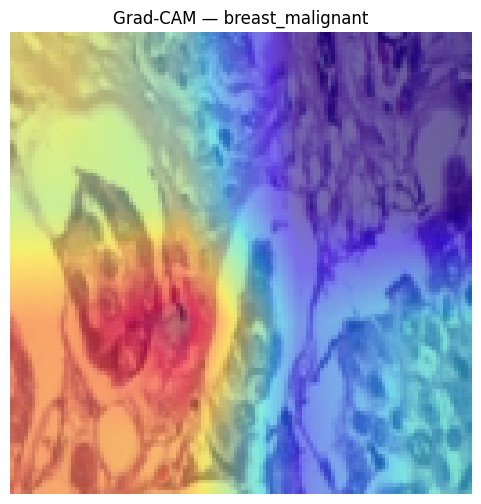

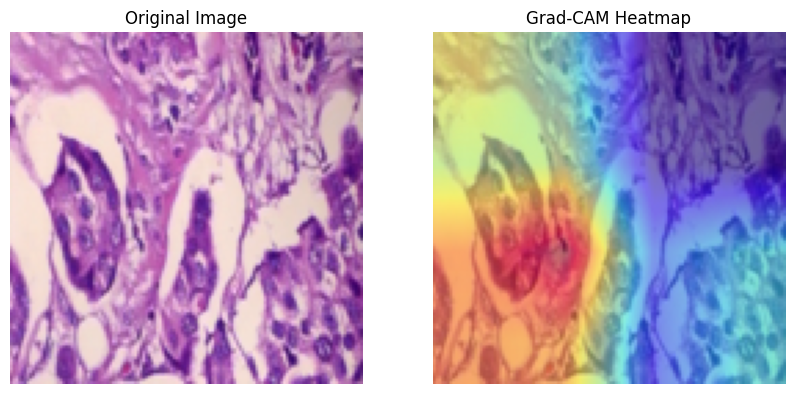

In [13]:
predict_with_GradCAM(
    "C:/Files/IISc/AI in Health Care/Multi Cancer/breast_malignant_0203.jpg",
    use_saved=True
)